# Tutorial on the construction of the structured mesh for the meridional plane of a centrifugal compressor

import all the relevant modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
import Grid

# Construction of the bladed block
import the correct datafiles, and instantiate a block object for the bladed zone

In [4]:
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 45
nspan = 20

hub = Grid.src.Curve(curve_filepath = data_folder_path+'iris_hub.curve', units = 'm', degree_spline=3)
shroud = Grid.src.Curve(curve_filepath = data_folder_path+'iris_shroud.curve', units = 'm', degree_spline=3)
bladed_block = Grid.src.Block(hub, shroud, blade_file = data_folder_path+'iris_blade.curve', block_type = 'blade', 
               nstream=nstream, nspan=nspan)

now instantiate a blade object, which contains the information relative to the blade. Thanks to those information you can find then the inlet and outlet points, which are the points located on the virtual leading and trailing edge

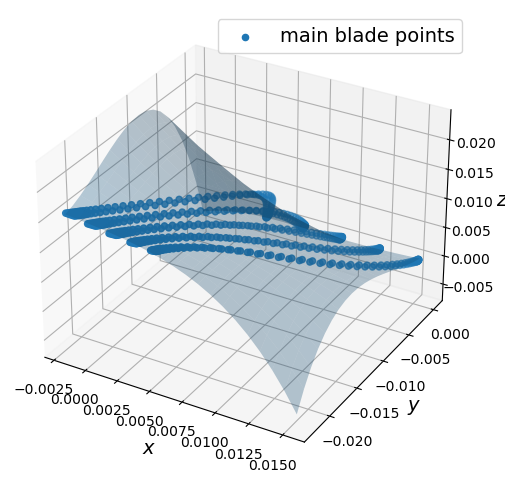

In [6]:
blade = Grid.src.Blade(data_folder_path+'iris_blade.curve')
blade.find_camber_surface()
blade.find_inlet_points()
blade.find_outlet_points()
blade.plot_camber_surface()

now give these info the block object, allowing it to find the intersections with the hub and shroud lines, leading to a correct trim of the block

In [7]:
bladed_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
bladed_block.extend_inlet_outlet_curves()
bladed_block.find_intersections()
bladed_block.bladed_zone_trim()
bladed_block.spline_of_trim()

now we can finally sample the various lines with a certain sampling algorithm, compute the primary and secondary grid points, and finally plot the grid:

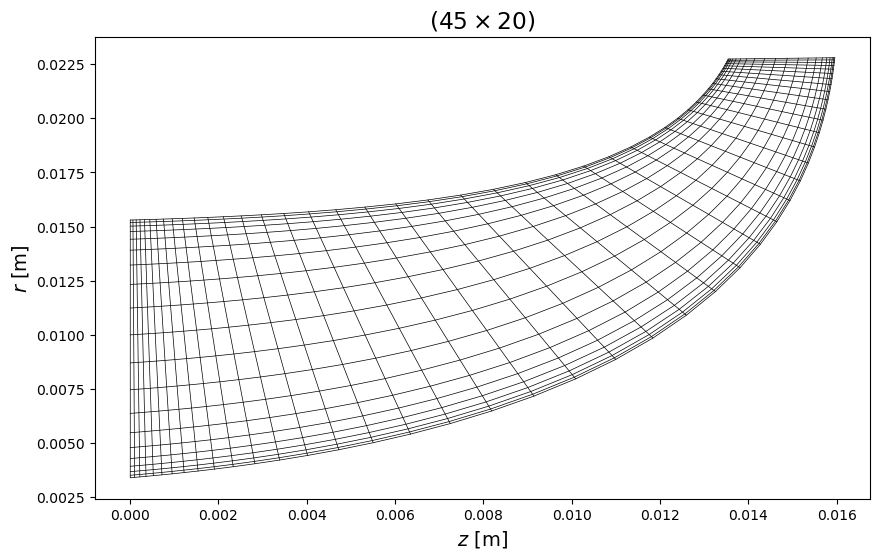

In [8]:
bladed_block.sample(sampling_mode='clustering')
bladed_block.compute_span_points(sampling_mode='clustering')
bladed_block.compute_double_grid()
bladed_block.plot_full_grid(secondary_grid=False)

## Inlet Zone Block
now we can do the same thing for the inlet block, paying attention simply to the trim locations, that for this block are specified only downstream, and corresponding to the leading edge of the blade

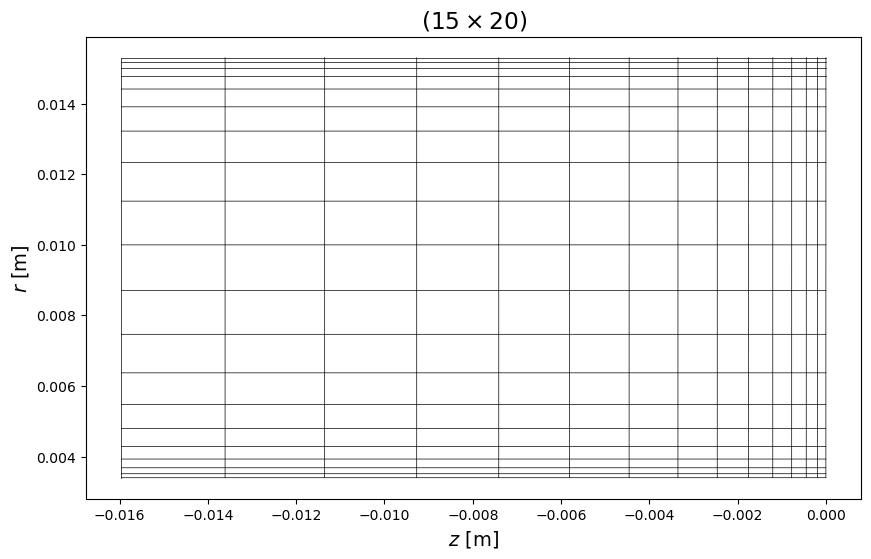

In [9]:
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 15
nspan = 20

hub = Grid.src.Curve(curve_filepath = data_folder_path+'iris_hub.curve', units = 'm', degree_spline=1)
shroud = Grid.src.Curve(curve_filepath = data_folder_path+'iris_shroud.curve', units = 'm', degree_spline=1)
inlet_block = Grid.src.Block(hub, shroud, blade_file = data_folder_path+'iris_blade.curve', block_type = 'blade', 
               nstream=nstream, nspan=nspan)

inlet_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
inlet_block.extend_inlet_outlet_curves()
inlet_block.find_intersections()
inlet_block.inlet_zone_trim()

inlet_block.spline_of_trim()
inlet_block.sample(sampling_mode='clustering_right')
inlet_block.compute_span_points(sampling_mode='clustering')
inlet_block.compute_double_grid()
inlet_block.plot_full_grid(secondary_grid=False)

## Outlet Zone Block
now we can do the same thing for the outlet block, paying attention simply to the trim locations, that for this block are specified only upstream, and corresponding to the trailing edge of the blade

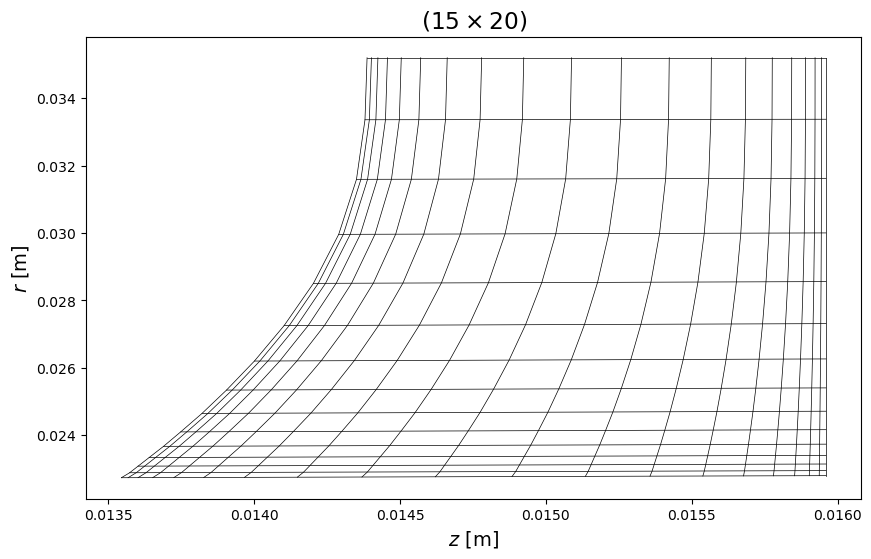

In [10]:
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 15
nspan = 20

hub = Grid.src.Curve(curve_filepath = data_folder_path+'iris_hub.curve', units = 'm', degree_spline=1)
shroud = Grid.src.Curve(curve_filepath = data_folder_path+'iris_shroud.curve', units = 'm', degree_spline=1)
outlet_block = Grid.src.Block(hub, shroud, blade_file = data_folder_path+'iris_blade.curve', block_type = 'blade', 
               nstream=nstream, nspan=nspan)

outlet_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
outlet_block.extend_inlet_outlet_curves()
outlet_block.find_intersections()
outlet_block.outlet_zone_trim()

outlet_block.spline_of_trim()
outlet_block.sample(sampling_mode='clustering_left')
outlet_block.compute_span_points(sampling_mode='clustering')
outlet_block.compute_double_grid()
outlet_block.plot_full_grid(secondary_grid=False)

## Construct the multiblock object
instantiate a multiblock object, which stores all the info of the other blocks, and let us see the full grid

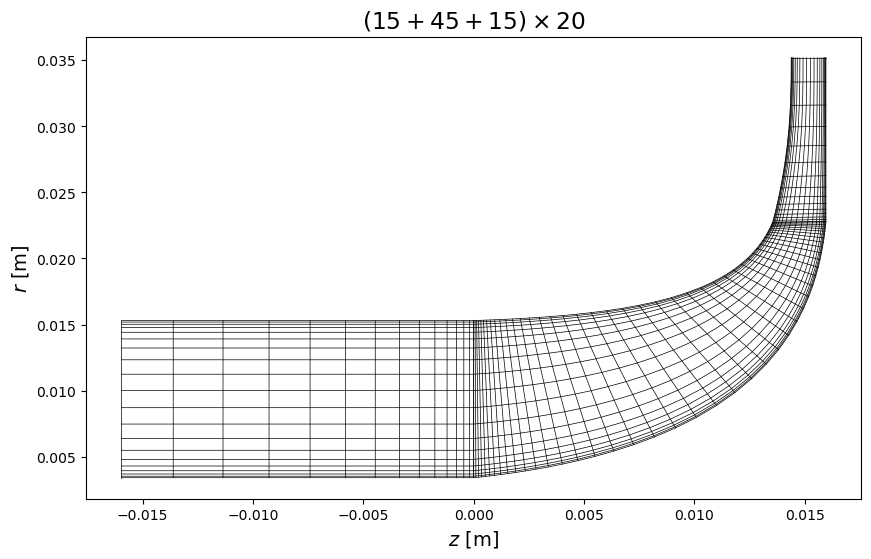

In [11]:
multiblock = Grid.src.Multiblock(units='m')
multiblock.add_block(inlet_block)
multiblock.add_block(bladed_block)
multiblock.add_block(outlet_block)
multiblock.assemble_multiblock()
multiblock.plot_full_grid()